# **3. Train and Test ML algorithm in Materials - Unsupervised Learning(Assignment)**

In [1]:
# Install libraries to use matminer.
# ⚠️ After running this once, please click the runtime button and restart the session/kernel
# and run the code again from a fresh session.
# Ignore the Error Message
!pip uninstall -y opencv-python opencv-contrib-python opencv-python-headless thinc -q
!pip install opencv-python==4.10.0.84 opencv-contrib-python==4.10.0.84 -q
!pip install thinc==8.1.12 -q
!pip install numpy==1.26.4 pandas==2.2.2 matplotlib==3.8.0 -q
!pip install pyyaml six -q
!pip install matminer pymatgen -q
#!git clone https://github.com/CMDDclass/MS697-material.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for thinc (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for thinc
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (thinc)


In [2]:
# Task: Load the elastic tensor dataset from matminer and keep only the columns
# "material_id", "K_VRH", "G_VRH", and "poisson_ratio"
from matminer.datasets.convenience_loaders import load_elastic_tensor

df = load_elastic_tensor()  # load the dataset in a pandas DataFrame object
print(df.columns)  # check columns
df = df[["material_id", "K_VRH", "G_VRH", "poisson_ratio"]]
df.head()


Fetching elastic_tensor_2015.json.gz from https://ndownloader.figshare.com/files/13220603 to /usr/local/lib/python3.12/dist-packages/matminer/datasets/elastic_tensor_2015.json.gz


Fetching https://ndownloader.figshare.com/files/13220603 in MB: 1.1182079999999999MB [00:00, 142.59MB/s]                


Index(['material_id', 'formula', 'nsites', 'space_group', 'volume',
       'structure', 'elastic_anisotropy', 'G_Reuss', 'G_VRH', 'G_Voigt',
       'K_Reuss', 'K_VRH', 'K_Voigt', 'poisson_ratio', 'compliance_tensor',
       'elastic_tensor', 'elastic_tensor_original'],
      dtype='object')


,material_id,K_VRH,G_VRH,poisson_ratio
0,mp-10003,194.268884,97.141604,0.285701
1,mp-10010,175.449907,96.252006,0.268105
2,mp-10015,295.077545,130.112955,0.307780
3,mp-10021,49.130670,15.101901,0.360593
4,mp-10025,256.768081,101.947798,0.324682


In [3]:
# Task: Exclude the column "material_id" from the dataset and create a new DataFrame X
# containing only the numerical feature columns
excluded = ["material_id"]
X = df.drop(excluded, axis=1)
X.head()


,K_VRH,G_VRH,poisson_ratio
0,194.268884,97.141604,0.285701
1,175.449907,96.252006,0.268105
2,295.077545,130.112955,0.307780
3,49.130670,15.101901,0.360593
4,256.768081,101.947798,0.324682


In [4]:
# Task: Perform unstructured Agglomerative Clustering (Ward linkage) on dataset X with 6 clusters,
# measure the elapsed time, and obtain the cluster labels

#The agglomerative clustering is the most common type of hierarchical clustering used to group objects in clusters based on their similarity.
#It’s also known as AGNES (Agglomerative Nesting). The algorithm starts by treating each object as a singleton cluster.
#Next, pairs of clusters are successively merged until all clusters have been merged into one big cluster containing all objects.
import time as time
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import AgglomerativeClustering
import sklearn.datasets
#The method of merging two clusters involves combining the two clusters that result in the smallest increase in the variance within all clusters.(Ward)
print("Compute unstructured hierarchical clustering...")
st = time.time()
ward = AgglomerativeClustering(n_clusters=6, linkage="ward").fit(X)
elapsed_time = time.time() - st
group = ward.labels_
print(f"Elapsed time: {elapsed_time:.2f}s")
print(f"Number of points: {group.size}")


Compute unstructured hierarchical clustering...
Elapsed time: 0.10s
Number of points: 1181


In [5]:
group

array([4, 4, 1, ..., 5, 5, 2])

In [6]:
# Task: Add the cluster labels as a new column "group" to the DataFrame and display the updated DataFrame
df['group'] = group.tolist()
df


,material_id,K_VRH,G_VRH,poisson_ratio,group
0,mp-10003,194.268884,97.141604,0.285701,4
1,mp-10010,175.449907,96.252006,0.268105,4
2,mp-10015,295.077545,130.112955,0.307780,1
3,mp-10021,49.130670,15.101901,0.360593,2
4,mp-10025,256.768081,101.947798,0.324682,1
...,...,...,...,...,...
1176,mp-9961,111.788114,53.329789,0.294196,5
1177,mp-9969,101.326807,70.253182,0.218412,5
1178,mp-9972,89.418161,65.160458,0.206850,5
1179,mp-998,99.384565,40.211802,0.321738,5


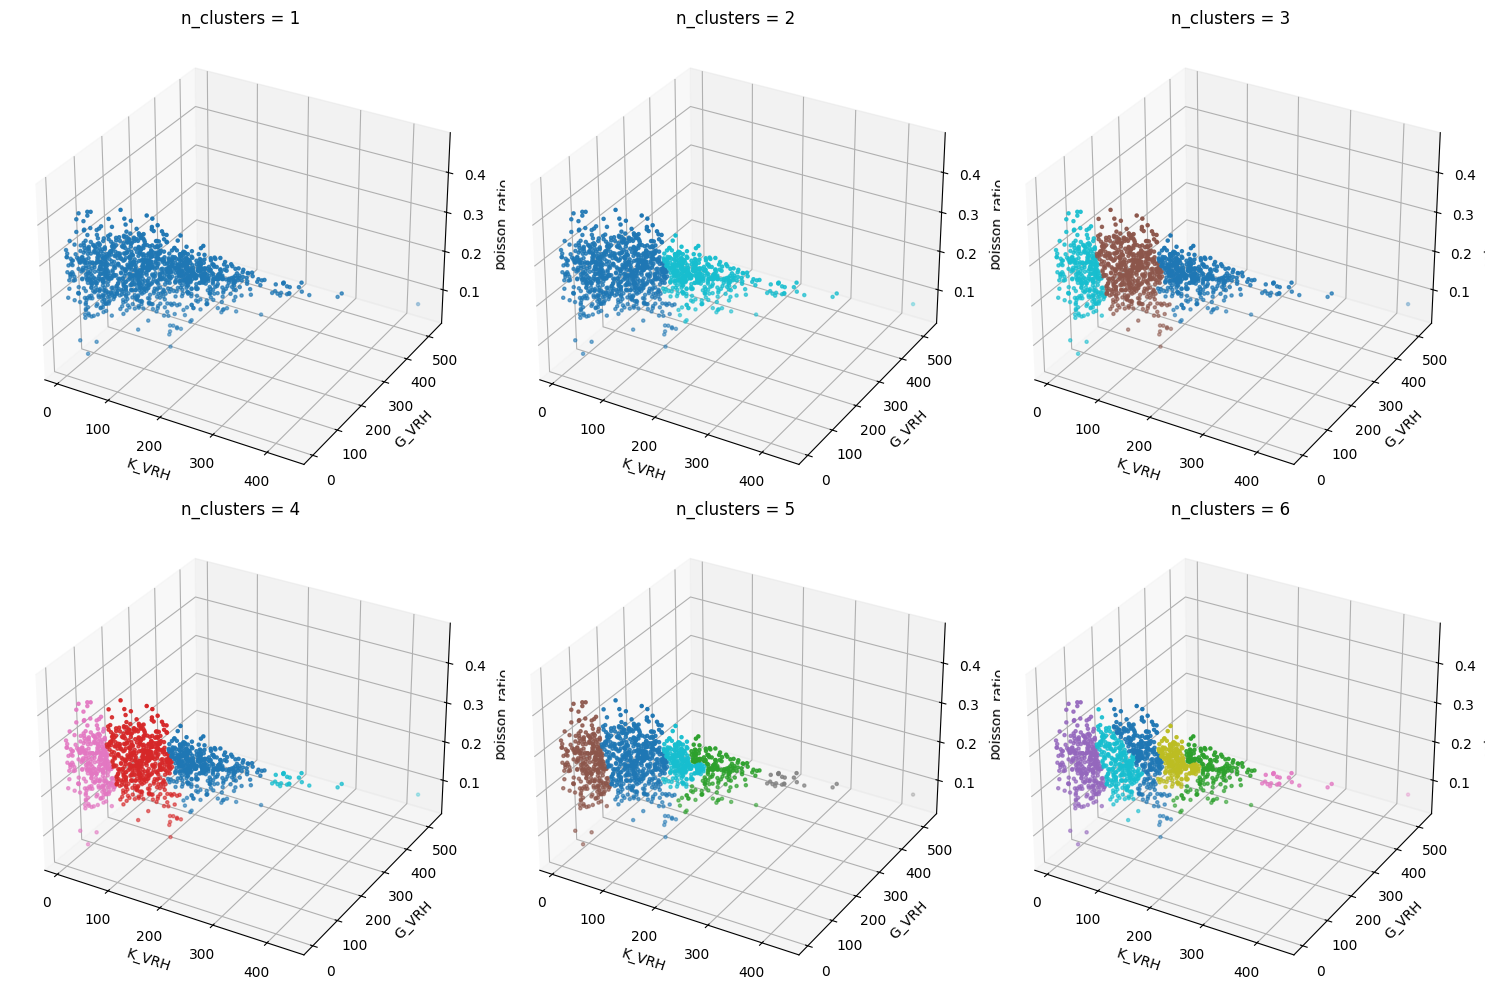

In [7]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from mpl_toolkits.mplot3d import Axes3D  # for 3D plotting

X_3D = df[["K_VRH", "G_VRH", "poisson_ratio"]].dropna()

fig = plt.figure(figsize=(15, 10))

for i, n_clusters in enumerate(range(1, 7), 1):  # 1 ~ 6 clusters
    ax = fig.add_subplot(2, 3, i, projection="3d")

    model = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
    labels = model.fit_predict(X_3D)

    ax.scatter(X_3D["K_VRH"], X_3D["G_VRH"], X_3D["poisson_ratio"],
               c=labels, cmap="tab10", s=5)

    ax.set_title(f"n_clusters = {n_clusters}")
    ax.set_xlabel("K_VRH")
    ax.set_ylabel("G_VRH")
    ax.set_zlabel("poisson_ratio")

plt.tight_layout()
plt.show()


In [8]:
# Task: Perform structured Agglomerative Clustering (Ward linkage) on dataset X with 5 clusters,
# using a k-nearest neighbors connectivity graph (n_neighbors = 5) to impose local connectivity constraints.
# Measure the elapsed time and obtain the cluster labels.

from sklearn.neighbors import kneighbors_graph

connectivity = kneighbors_graph(X, n_neighbors=5, include_self=False)
print("Compute structured hierarchical clustering...")
st = time.time()
ward = AgglomerativeClustering(
    n_clusters=5, connectivity=connectivity, linkage="ward"
).fit(X)
elapsed_time = time.time() - st
group = ward.labels_
print(f"Elapsed time: {elapsed_time:.2f}s")
print(f"Number of points: {group.size}")


Compute structured hierarchical clustering...
Elapsed time: 0.26s
Number of points: 1181


In [9]:
group

array([4, 4, 1, ..., 0, 0, 2])

In [10]:
# Task: Add the cluster labels as a new column "group" to the DataFrame and display the updated DataFrame
df['group'] = group.tolist()
df


,material_id,K_VRH,G_VRH,poisson_ratio,group
0,mp-10003,194.268884,97.141604,0.285701,4
1,mp-10010,175.449907,96.252006,0.268105,4
2,mp-10015,295.077545,130.112955,0.307780,1
3,mp-10021,49.130670,15.101901,0.360593,2
4,mp-10025,256.768081,101.947798,0.324682,1
...,...,...,...,...,...
1176,mp-9961,111.788114,53.329789,0.294196,0
1177,mp-9969,101.326807,70.253182,0.218412,0
1178,mp-9972,89.418161,65.160458,0.206850,0
1179,mp-998,99.384565,40.211802,0.321738,0


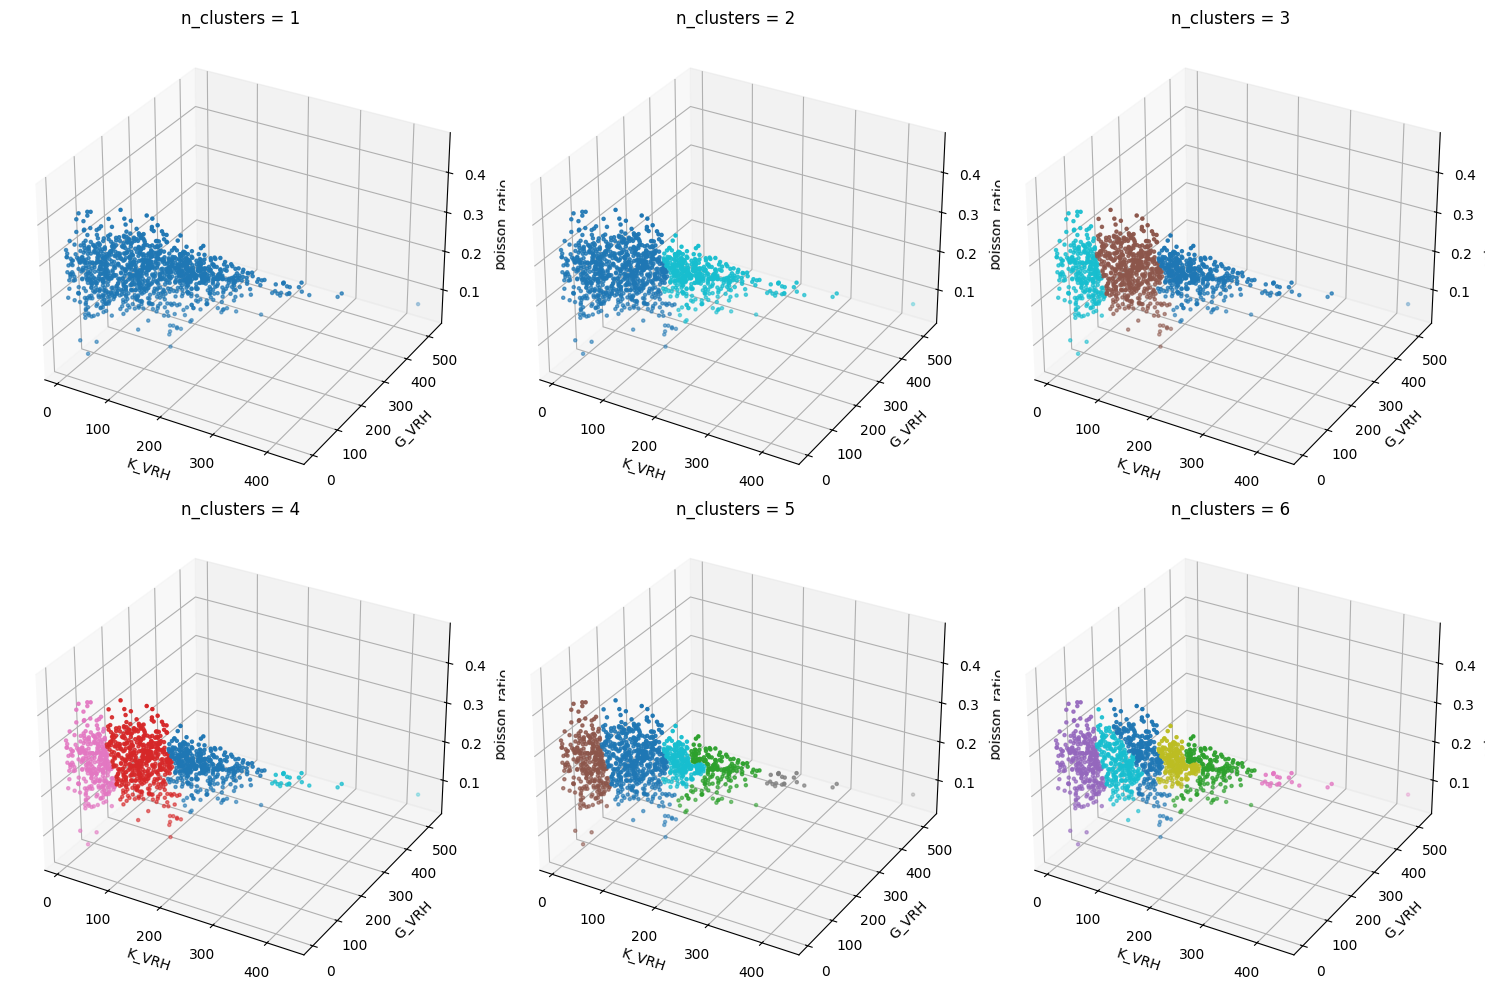

In [12]:
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from mpl_toolkits.mplot3d import Axes3D  # for 3D plotting

X_3D = df[["K_VRH", "G_VRH", "poisson_ratio"]].dropna()

fig = plt.figure(figsize=(15, 10))

for i, n_clusters in enumerate(range(1, 7), 1):  # 1 ~ 6 clusters
    ax = fig.add_subplot(2, 3, i, projection="3d")
    connectivity = kneighbors_graph(X, n_neighbors=5, include_self=False)
    model = AgglomerativeClustering(n_clusters=n_clusters, connectivity = connectivity, linkage="ward")
    labels = model.fit_predict(X_3D)

    ax.scatter(X_3D["K_VRH"], X_3D["G_VRH"], X_3D["poisson_ratio"],
               c=labels, cmap="tab10", s=5)

    ax.set_title(f"n_clusters = {n_clusters}")
    ax.set_xlabel("K_VRH")
    ax.set_ylabel("G_VRH")
    ax.set_zlabel("poisson_ratio")

plt.tight_layout()
plt.show()

